# **CCA**
*Analyse canonique des correlations*

In [30]:
import pandas as pd

# importation du dataset
df = pd.read_csv("../data/cumulative_cleaned.csv")

# On définit deux groupes X et Y (physique de la planète et de l'étoile hôte)
# X (Planète) : koi_period, koi_duration, koi_depth, koi_prad, koi_teq, koi_impact.
# Y (Étoile) : koi_steff, koi_slogg, koi_srad, koi_kepmag.

X_cols = ['koi_period', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_impact', 'koi_teq']
Y_cols = ['koi_steff', 'koi_slogg', 'koi_srad', 'koi_kepmag']
X = df[X_cols]
Y = df[Y_cols]

Dans le cas de notre étude, nous disposons de données physiques brutes : rayons, périodes orbitales, profondeurs de transit, températures, flux reçus, etc. Ces variables sont souvent liées par des formules physiques impliquant des puissances ou des lois non linéaires.

Ces puissances compliquent l’analyse par Canonical Correlation Analysis (CCA), qui fonctionne mieux sur des relations linéaires entre variables. Pour résoudre ce problème, nous appliquons finalement une transformation logarithmique (log1p) à toutes les variables numériques. Cette transformation permet de convertir les lois de puissance en relations linéaires.

In [31]:
# Log Transform (np.log1p) sur toutes les variables.
import numpy as np

cols_to_log = ['koi_prad', 'koi_depth', 'koi_srad', 'koi_period', 'koi_impact', 'koi_duration', 'koi_teq', 'koi_steff', 'koi_kepmag', 'koi_slogg']

for col in cols_to_log:
    df[col] = np.log1p(df[col])
    print(f"Log transform appliqué à {col}")
    
print("\nTransformations logarithmiques appliquées aux colonnes spécifiées.\n")

Log transform appliqué à koi_prad
Log transform appliqué à koi_depth
Log transform appliqué à koi_srad
Log transform appliqué à koi_period
Log transform appliqué à koi_impact
Log transform appliqué à koi_duration
Log transform appliqué à koi_teq
Log transform appliqué à koi_steff
Log transform appliqué à koi_kepmag
Log transform appliqué à koi_slogg

Transformations logarithmiques appliquées aux colonnes spécifiées.



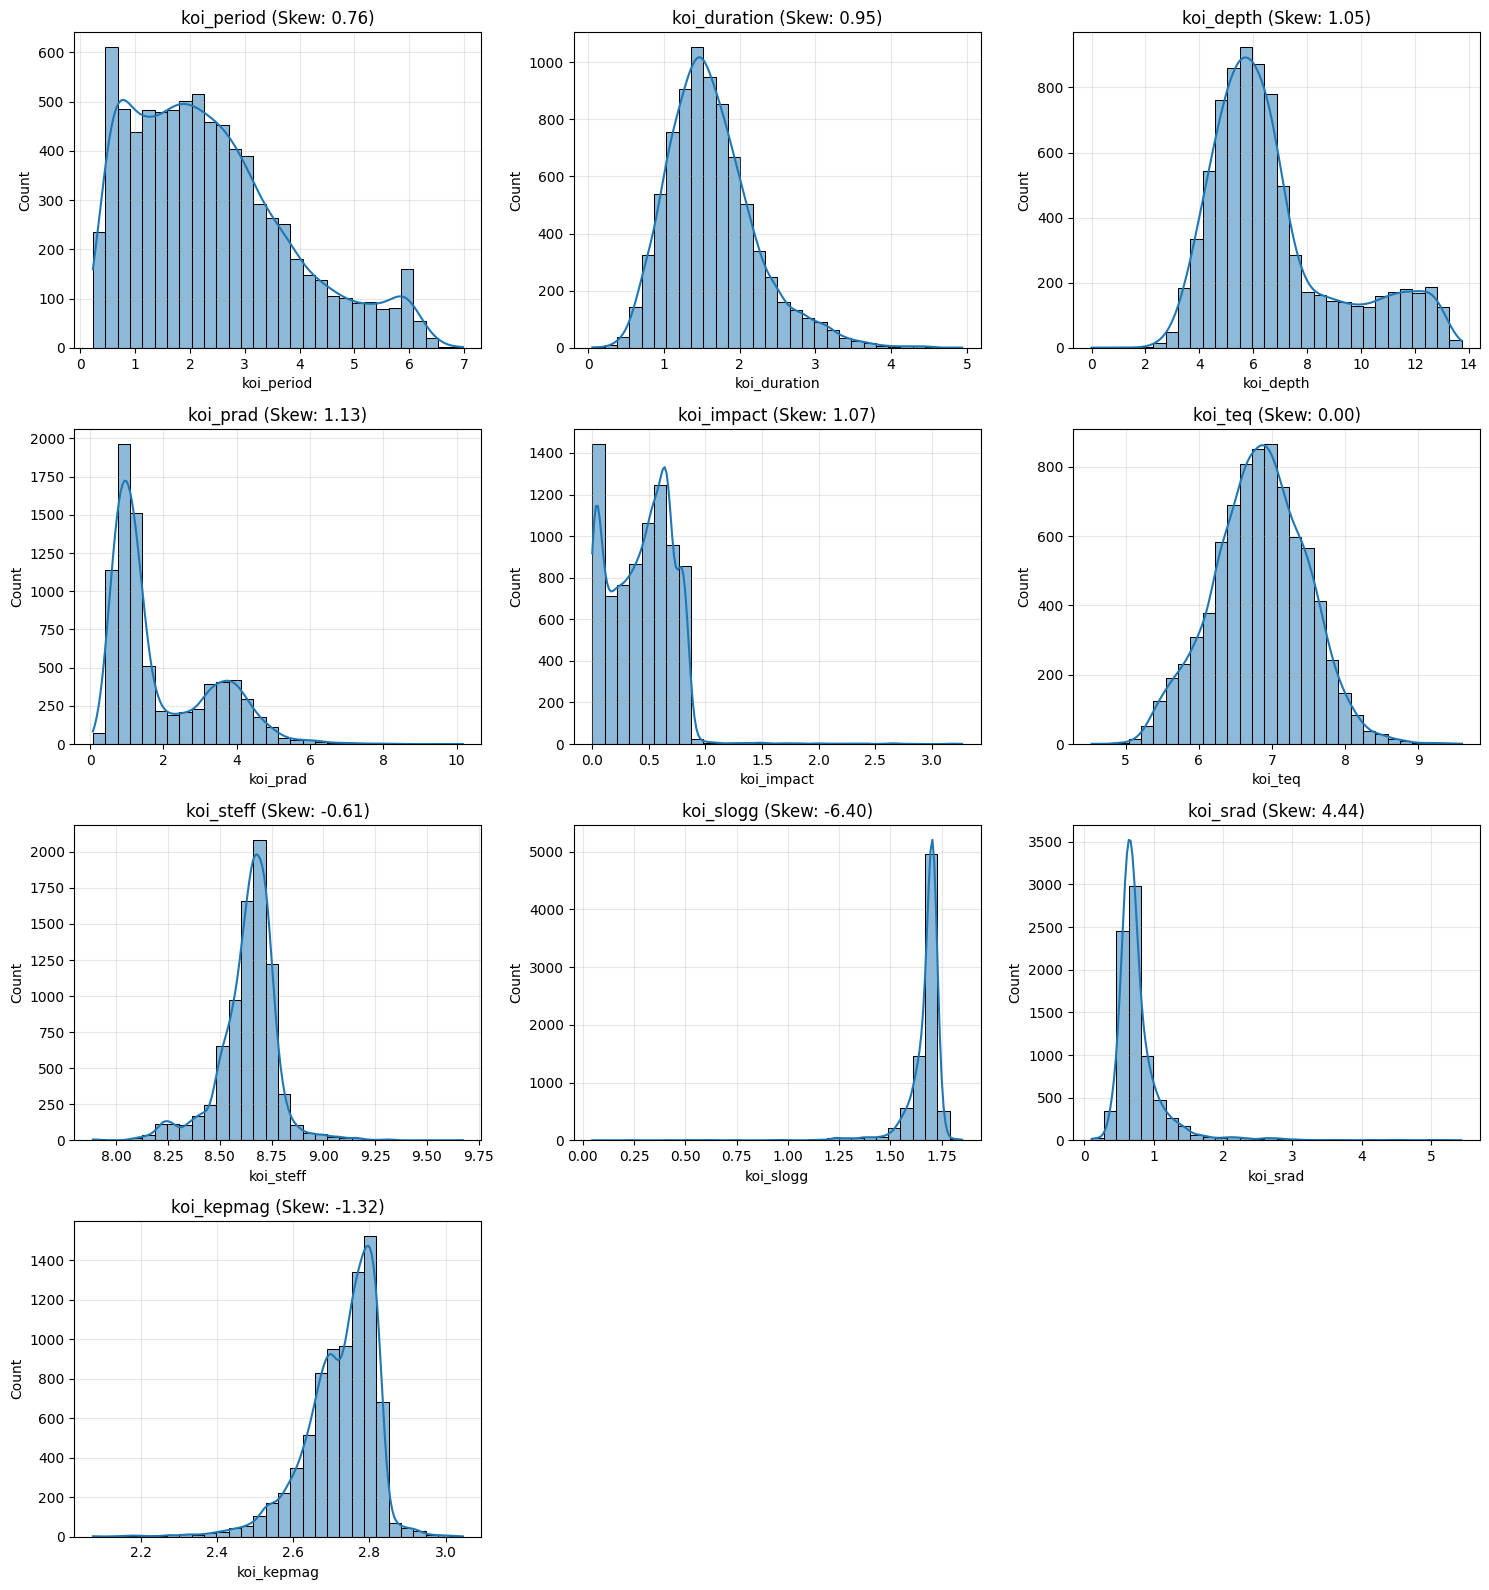

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisation (Histogrammes)
all_cols = X_cols + Y_cols
n_cols = 3
n_rows = (len(all_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 4 * n_rows))
for i, col in enumerate(all_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"{col} (Skew: {df[col].skew():.2f})")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Application de l’Analyse Canonique des Corrélations (CCA)**

In [33]:
from sklearn.preprocessing import StandardScaler

# On repart de ton dataframe df qui contient déjà les logs
# On sélectionne les colonnes X et Y
X_data = df[X_cols]
Y_data = df[Y_cols]

# Initialisation du Scaler
scaler_x = StandardScaler()
scaler_y = StandardScaler()

# Centrage et Réduction (Moyenne = 0, Variance = 1)
X_scaled = scaler_x.fit_transform(X_data)
Y_scaled = scaler_y.fit_transform(Y_data)

# On remet en DataFrame pour la lisibilité
X_scaled = pd.DataFrame(X_scaled, columns=X_cols)
Y_scaled = pd.DataFrame(Y_scaled, columns=Y_cols)

print("Moyennes après scaling (doit être 0) :\n", X_scaled.mean().round(2))
print("Écart-types après scaling (doit être 1) :\n", X_scaled.std().round(2))

Moyennes après scaling (doit être 0) :
 koi_period     -0.0
koi_duration    0.0
koi_depth      -0.0
koi_prad       -0.0
koi_impact     -0.0
koi_teq        -0.0
dtype: float64
Écart-types après scaling (doit être 1) :
 koi_period      1.0
koi_duration    1.0
koi_depth       1.0
koi_prad        1.0
koi_impact      1.0
koi_teq         1.0
dtype: float64


In [34]:
from sklearn.cross_decomposition import CCA

# Nombre de composantes : min(6 variables X, 4 variables Y) = 4
n_comp = 4
cca = CCA(n_components=n_comp)

# Entraînement du modèle (calcul des a_k et b_k)
cca.fit(X_scaled, Y_scaled)

# Projection des données (Calcul des V_k et W_k)
# Référence Page 41 : V = X * a, W = Y * b
X_c, Y_c = cca.transform(X_scaled, Y_scaled)

print(f"CCA effectué avec {n_comp} composantes.")

CCA effectué avec 4 composantes.


--- Corrélations Canoniques ---
Dimension 1 : 0.9784
Dimension 2 : 0.4248
Dimension 3 : 0.1660
Dimension 4 : 0.0103


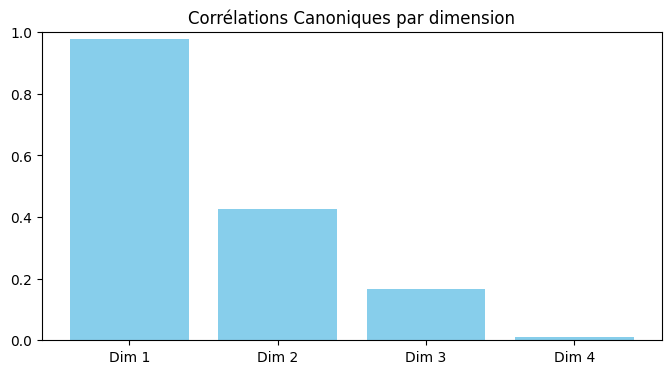

In [35]:
import numpy as np

# Calcul manuel des corrélations entre les paires de variables canoniques (V_k, W_k)
corrs = [np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1] for i in range(n_comp)]

print("--- Corrélations Canoniques ---")
for i, corr in enumerate(corrs):
    print(f"Dimension {i+1} : {corr:.4f}")

# Visuel simple (Scree plot des corrélations)
plt.figure(figsize=(8, 4))
plt.bar([f"Dim {i+1}" for i in range(n_comp)], corrs, color='skyblue')
plt.title("Corrélations Canoniques par dimension")
plt.ylim(0, 1)
plt.show()

In [36]:
from scipy.stats import chi2

def bartlett_test(corrs, n, p, q):
    """Implémentation du test de la Page 52"""
    eigenvalues = np.array(corrs)**2 # lambda = corrélation²
    results = []
    
    for k in range(len(eigenvalues)):
        # On teste les corrélations de k à la fin (Page 52, deuxième formule)
        lambdas_remaining = eigenvalues[k:]
        stat_test = -(n - (p + q + 3) / 2) * np.sum(np.log(1 - lambdas_remaining))
        
        # Degrés de liberté : (p-k)*(q-k)
        df = (p - k) * (q - k)
        
        # p-value
        p_val = 1 - chi2.cdf(stat_test, df)
        
        results.append({
            "Dimensions testées": f"{k+1} à {len(eigenvalues)}",
            "Statistique Chi2": stat_test,
            "p-value": p_val,
            "Significatif (99%)": p_val < 0.01
        })
    return pd.DataFrame(results)

n = len(df)
p = len(X_cols)
q = len(Y_cols)

print(bartlett_test(corrs, n, p, q))

  Dimensions testées  Statistique Chi2   p-value  Significatif (99%)
0              1 à 4      26990.706136  0.000000                True
1              2 à 4       1813.972038  0.000000                True
2              3 à 4        224.131997  0.000000                True
3              4 à 4          0.853963  0.836521               False


Le test de Bartlett basé sur la statistique du χ² montre que les corrélations canoniques entre les paramètres planétaires et stellaires sont globalement significatives (p < 0.01).
La première dimension canonique est fortement significative, indiquant une relation physique dominante entre les propriétés des planètes et celles de leur étoile hôte.
Les dimensions canoniques suivantes ne sont pas statistiquement significatives au seuil de 1 %, ce qui suggère que l’essentiel de la dépendance X–Y est capturé par la première (éventuellement la seconde) composante.

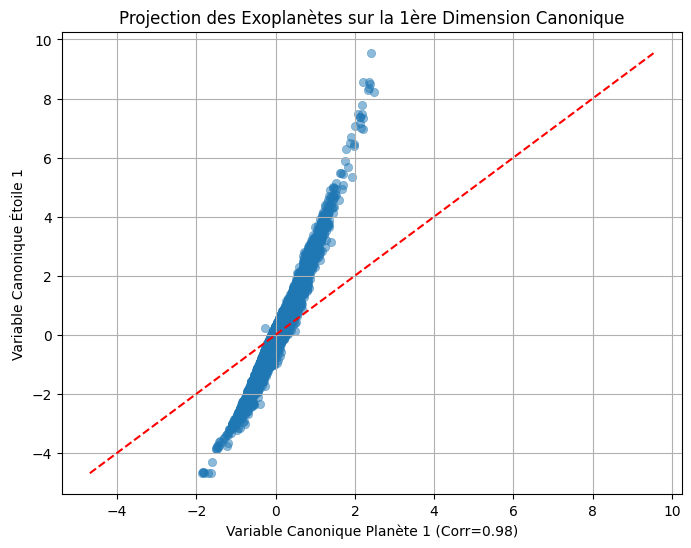

In [37]:
plt.figure(figsize=(8, 6))

# On projette les exoplanètes sur le premier plan canonique (Dim 1 X vs Dim 1 Y)
sns.scatterplot(x=X_c[:, 0], y=Y_c[:, 0], alpha=0.5, edgecolor=None)

# On trace la diagonale parfaite
min_val = min(X_c[:, 0].min(), Y_c[:, 0].min())
max_val = max(X_c[:, 0].max(), Y_c[:, 0].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel(f"Variable Canonique Planète 1 (Corr={corrs[0]:.2f})")
plt.ylabel(f"Variable Canonique Étoile 1")
plt.title("Projection des Exoplanètes sur la 1ère Dimension Canonique")
plt.grid(True)
plt.show()

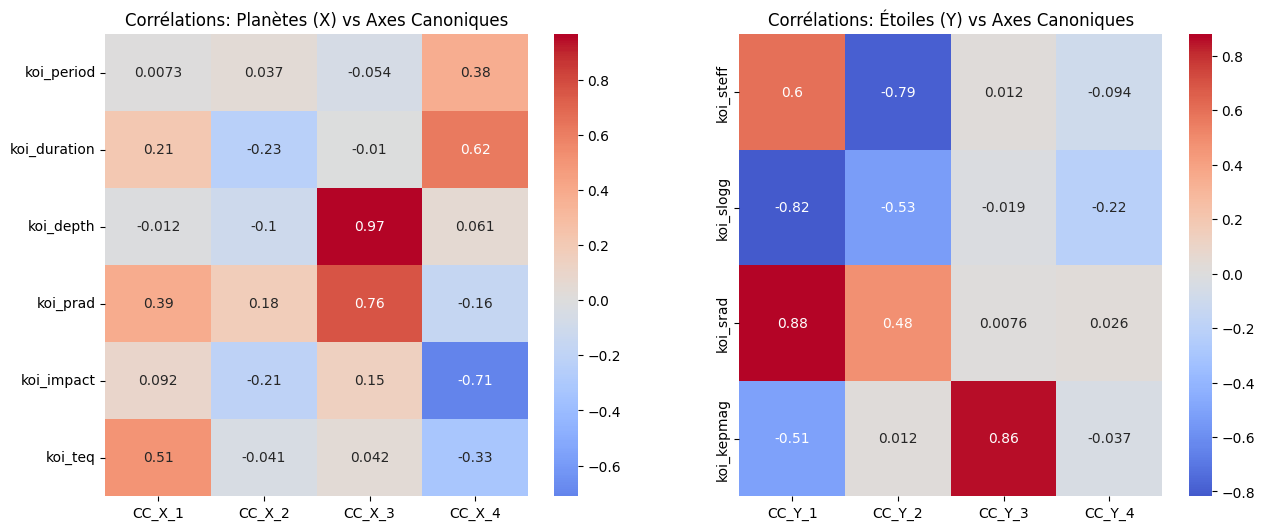

In [38]:
# Matrice de corrélation Variables Originales X vs Variables Canoniques X (Table 1 gauche)
# On regarde les deux premières dimensions principalement
loadings_X = pd.DataFrame(
    np.corrcoef(X_scaled.T, X_c.T)[:len(X_cols), len(X_cols):],
    index=X_cols,
    columns=[f"CC_X_{i+1}" for i in range(n_comp)]
)

# Matrice de corrélation Variables Originales Y vs Variables Canoniques Y (Table 1 droite)
loadings_Y = pd.DataFrame(
    np.corrcoef(Y_scaled.T, Y_c.T)[:len(Y_cols), len(Y_cols):],
    index=Y_cols,
    columns=[f"CC_Y_{i+1}" for i in range(n_comp)]
)

import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(loadings_X, annot=True, cmap="coolwarm", center=0, ax=ax[0])
ax[0].set_title("Corrélations: Planètes (X) vs Axes Canoniques")

sns.heatmap(loadings_Y, annot=True, cmap="coolwarm", center=0, ax=ax[1])
ax[1].set_title("Corrélations: Étoiles (Y) vs Axes Canoniques")
plt.show()

**Équation de Température**

L'obtention d'un score de corrélation de 0.99 nous a alertés sur une anomalie. Cette anomalie est liée à la dépendance physique décrite par l’équation de la chaleur, qui régit le transfert d’énergie entre l’étoile et la planète.

L’équation montre que la température d’équilibre de la planète est directement déterminée par le flux reçu de l’étoile, ce qui rend koi_teq quasi déterministe à partir des caractéristiques stellaires et provoque un data leakage dans nos modèles.

**--> on retire koi_teq du groupe X**

In [39]:
import pandas as pd

# On redéfinit deux groupes X et Y (physique de la planète et de l'étoile hôte)
# X (Planète) : koi_period, koi_duration, koi_depth, koi_prad, koi_impact.
# Y (Étoile) : koi_steff, koi_slogg, koi_srad, koi_kepmag.

X_cols = ['koi_period', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_impact']
Y_cols = ['koi_steff', 'koi_slogg', 'koi_srad', 'koi_kepmag']
X = df[X_cols]
Y = df[Y_cols]

**Application de l’Analyse Canonique des Corrélations (CCA)**

In [40]:
from sklearn.preprocessing import StandardScaler

# On repart de ton dataframe df qui contient déjà les logs
# On sélectionne les colonnes X et Y
X_data = df[X_cols]
Y_data = df[Y_cols]

# Initialisation du Scaler
scaler_x = StandardScaler()
scaler_y = StandardScaler()

# Centrage et Réduction (Moyenne = 0, Variance = 1)
X_scaled = scaler_x.fit_transform(X_data)
Y_scaled = scaler_y.fit_transform(Y_data)

# On remet en DataFrame pour la lisibilité
X_scaled = pd.DataFrame(X_scaled, columns=X_cols)
Y_scaled = pd.DataFrame(Y_scaled, columns=Y_cols)

print("Moyennes après scaling (doit être 0) :\n", X_scaled.mean().round(2))
print("Écart-types après scaling (doit être 1) :\n", X_scaled.std().round(2))

Moyennes après scaling (doit être 0) :
 koi_period     -0.0
koi_duration    0.0
koi_depth      -0.0
koi_prad       -0.0
koi_impact     -0.0
dtype: float64
Écart-types après scaling (doit être 1) :
 koi_period      1.0
koi_duration    1.0
koi_depth       1.0
koi_prad        1.0
koi_impact      1.0
dtype: float64


In [41]:
from sklearn.cross_decomposition import CCA

# Nombre de composantes : min(5 variables X, 4 variables Y) = 4
n_comp = 4
cca = CCA(n_components=n_comp)

# Entraînement du modèle (calcul des a_k et b_k)
cca.fit(X_scaled, Y_scaled)

# Projection des données (Calcul des V_k et W_k)
# V = X * a, W = Y * b
X_c, Y_c = cca.transform(X_scaled, Y_scaled)

print(f"CCA effectué avec {n_comp} composantes.")

CCA effectué avec 4 composantes.


--- Corrélations Canoniques ---
Dimension 1 : 0.7591
Dimension 2 : 0.2357
Dimension 3 : 0.1659
Dimension 4 : 0.0102


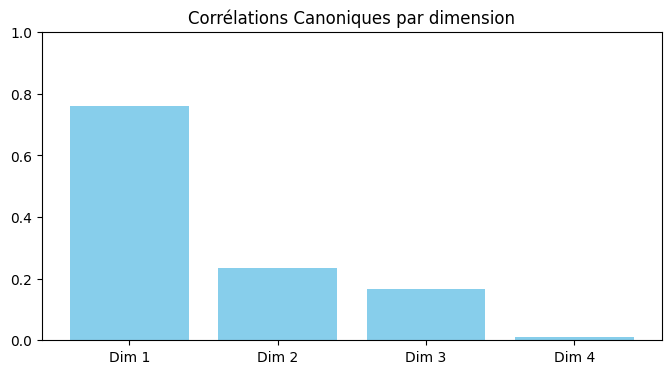

In [42]:
import numpy as np

# Calcul manuel des corrélations entre les paires de variables canoniques (V_k, W_k)
corrs = [np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1] for i in range(n_comp)]

print("--- Corrélations Canoniques ---")
for i, corr in enumerate(corrs):
    print(f"Dimension {i+1} : {corr:.4f}")

# Scree plot des corrélations
plt.figure(figsize=(8, 4))
plt.bar([f"Dim {i+1}" for i in range(n_comp)], corrs, color='skyblue')
plt.title("Corrélations Canoniques par dimension")
plt.ylim(0, 1)
plt.show()

In [43]:
from scipy.stats import chi2

def bartlett_test(corrs, n, p, q):
    """Implémentation du test de la Page 52"""
    eigenvalues = np.array(corrs)**2 # lambda = corrélation²
    results = []
    
    for k in range(len(eigenvalues)):
        # On teste les corrélations de k à la fin (Page 52, deuxième formule)
        lambdas_remaining = eigenvalues[k:]
        stat_test = -(n - (p + q + 3) / 2) * np.sum(np.log(1 - lambdas_remaining))
        
        # Degrés de liberté : (p-k)*(q-k)
        df = (p - k) * (q - k)
        
        # p-value
        p_val = 1 - chi2.cdf(stat_test, df)
        
        results.append({
            "Dimensions testées": f"{k+1} à {len(eigenvalues)}",
            "Statistique Chi2": stat_test,
            "p-value": p_val,
            "Significatif (99%)": p_val < 0.01
        })
    return pd.DataFrame(results)

n = len(df)
p = len(X_cols)
q = len(Y_cols)

print(bartlett_test(corrs, n, p, q))

  Dimensions testées  Statistique Chi2   p-value  Significatif (99%)
0              1 à 4       7538.253368  0.000000                True
1              2 à 4        680.120483  0.000000                True
2              3 à 4        223.684530  0.000000                True
3              4 à 4          0.831882  0.659719               False


Après suppression de la variable dérivée de température d’équilibre, le test de Bartlett basé sur la statistique du χ² indique que les trois premières corrélations canoniques entre les paramètres planétaires et stellaires sont statistiquement significatives au seuil de 1 %, tandis que la quatrième ne l’est pas.

Cela montre que la dépendance planète–étoile ne se résume pas à un seul mécanisme dominant, mais s’organise autour de plusieurs relations physiques indépendantes.

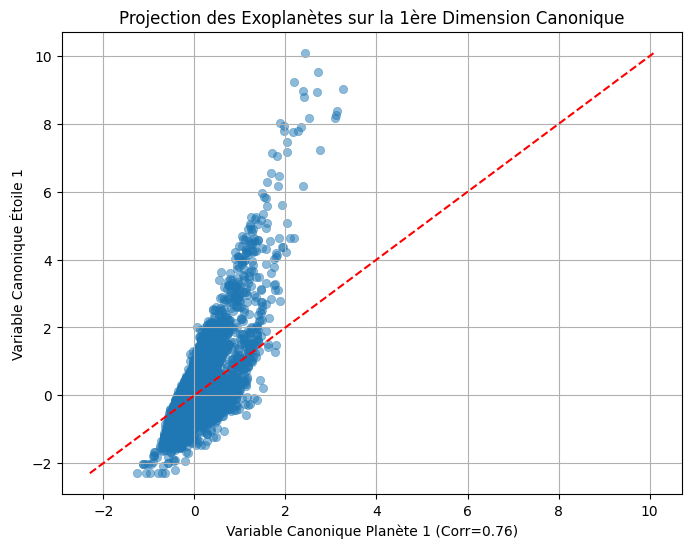

In [44]:
plt.figure(figsize=(8, 6))

# On projette les exoplanètes sur le premier plan canonique (Dim 1 X vs Dim 1 Y)
sns.scatterplot(x=X_c[:, 0], y=Y_c[:, 0], alpha=0.5, edgecolor=None)

# On trace la diagonale parfaite
min_val = min(X_c[:, 0].min(), Y_c[:, 0].min())
max_val = max(X_c[:, 0].max(), Y_c[:, 0].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel(f"Variable Canonique Planète 1 (Corr={corrs[0]:.2f})")
plt.ylabel(f"Variable Canonique Étoile 1")
plt.title("Projection des Exoplanètes sur la 1ère Dimension Canonique")
plt.grid(True)
plt.show()

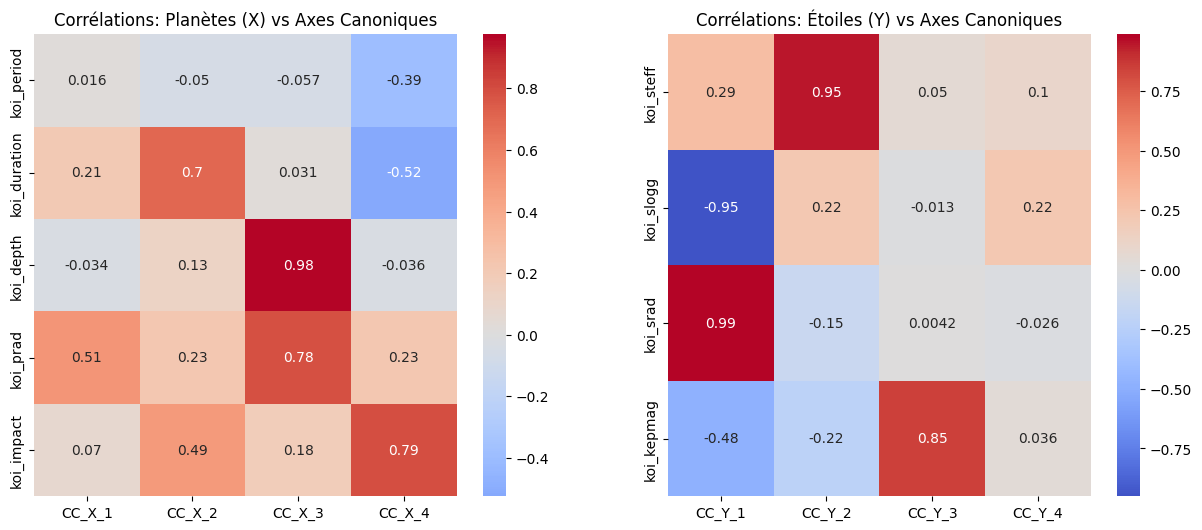

In [45]:
# Matrice de corrélation Variables Originales X vs Variables Canoniques X (Table 1 gauche)
# On regarde les deux premières dimensions principalement
loadings_X = pd.DataFrame(
    np.corrcoef(X_scaled.T, X_c.T)[:len(X_cols), len(X_cols):],
    index=X_cols,
    columns=[f"CC_X_{i+1}" for i in range(n_comp)]
)

# Matrice de corrélation Variables Originales Y vs Variables Canoniques Y (Table 1 droite)
loadings_Y = pd.DataFrame(
    np.corrcoef(Y_scaled.T, Y_c.T)[:len(Y_cols), len(Y_cols):],
    index=Y_cols,
    columns=[f"CC_Y_{i+1}" for i in range(n_comp)]
)

import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(loadings_X, annot=True, cmap="coolwarm", center=0, ax=ax[0])
ax[0].set_title("Corrélations: Planètes (X) vs Axes Canoniques")

sns.heatmap(loadings_Y, annot=True, cmap="coolwarm", center=0, ax=ax[1])
ax[1].set_title("Corrélations: Étoiles (Y) vs Axes Canoniques")
plt.show()

La première dimension canonique met en évidence une corrélation forte entre le rayon planétaire, le rayon de l’étoile hôte et la profondeur du transit. Cette structure statistique correspond directement à la relation physique bien connue reliant la profondeur du transit au rapport des rayons de la planète et de l’étoile, 𝛿≃(𝑅𝑝/𝑅∗)².